In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("Housing_Cleaned.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df[["price", "area"]].mean()

price    4.766729e+06
area     5.150541e+03
dtype: float64

In [7]:
df[["price", "area"]].var()

price    3.498544e+12
area     4.709512e+06
dtype: float64

In [8]:
df[["price", "area"]].std()

price    1.870440e+06
area     2.170141e+03
dtype: float64

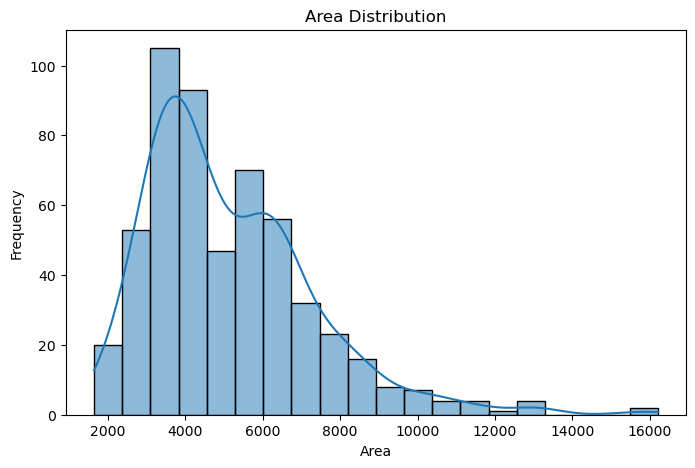

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["area"], bins=20, kde=True)
plt.title("Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

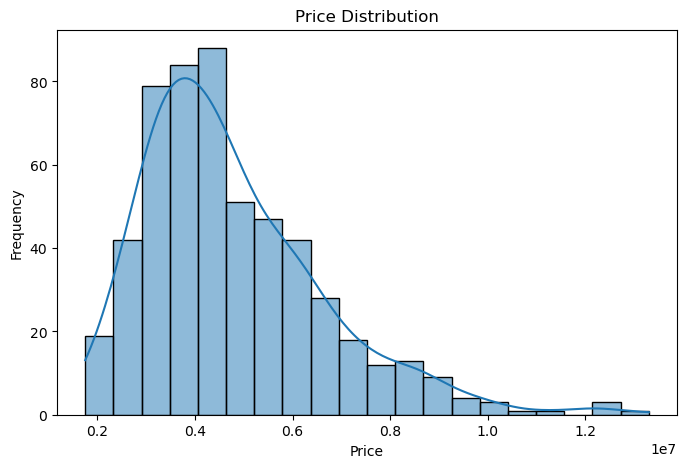

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=20, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [11]:
price_probability = df["price"].value_counts(normalize=True)

print(price_probability.head())

price
3500000    0.031193
4200000    0.031193
4900000    0.022018
3150000    0.016514
5600000    0.016514
Name: proportion, dtype: float64


In [12]:
furnished = df[df["furnishingstatus"] == "furnished"]["price"]
unfurnished = df[df["furnishingstatus"] == "unfurnished"]["price"]

print("Average Price (Furnished):", furnished.mean())
print("Average Price (Unfurnished):", unfurnished.mean())

Average Price (Furnished): 5495696.0
Average Price (Unfurnished): 4013831.4606741574


In [13]:
t_stat, p_value = stats.ttest_ind(furnished, unfurnished)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 6.884687359310765
P-Value: 3.1284706229043413e-11


In [14]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("There is a significant difference in price between furnished and unfurnished houses.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("There is no significant difference in price between furnished and unfurnished houses.")

Reject the Null Hypothesis (H0)
There is a significant difference in price between furnished and unfurnished houses.


In [15]:
correlation = df[["price","area","bedrooms","bathrooms","stories","parking"]].corr()

print(correlation)

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


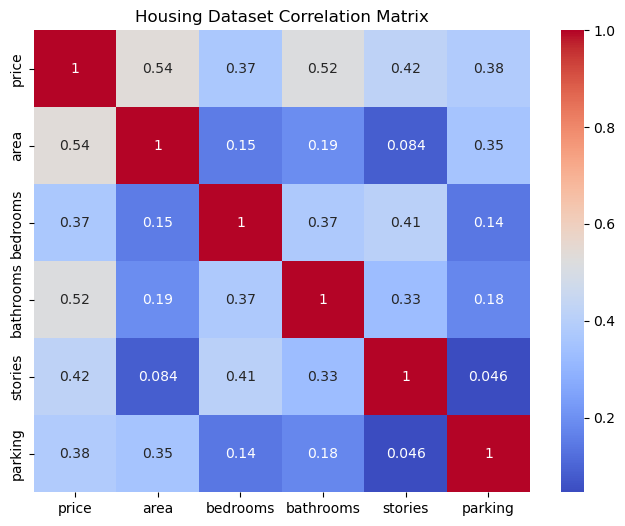

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Housing Dataset Correlation Matrix")
plt.show()

## Correlation vs Causation

Correlation measures the strength of the relationship between two variables, while causation means that one variable directly causes changes in another.

In this housing dataset, price is positively correlated with area and bathrooms, meaning larger houses with more bathrooms generally have higher prices. However, correlation does not necessarily imply causation because other factors such as location, furnishing status, and amenities may also influence house prices.